In [2]:
import numpy as np
import pandas as pd
import math as m
import json
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

from nods.core import NODS
from utils import *
from simulateEBCC import *

params_filename = '/home/csartor1/code/nearlab_repo/NODS/nods/model_parameters.json'

with open(params_filename, "r") as read_file:
    params = json.load(read_file)

t_sim  = 1000 # simulation time [ms] 
t0     = 0 #[ms] 
dt     = 1 #[ms] 
time   = np.arange(t0,t_sim,dt) #[ms] 

# Core functions explained - Single Source Simulation

### Define source activity 

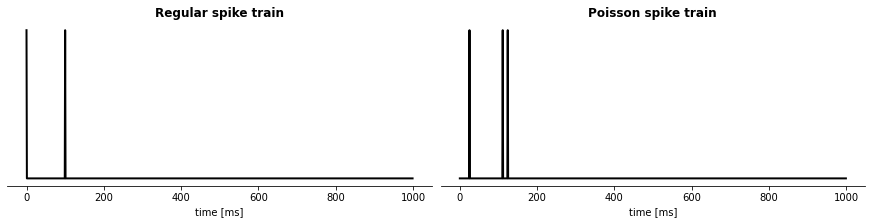

In [5]:
start = 0
stop = 200
input_rate = 10
spike_train_type = 'regular'

spikes_poisson = homogeneous_poisson(input_rate/1000, start, stop, dt, len(time))
t_poisson = np.arange(len(spikes_poisson)) * dt
time_stamps_poisson = t_poisson[spikes_poisson.astype(bool)]

spikes_regular = regular_spikes(start,stop,dt,input_rate,len(time))
t_regular = np.arange(len(spikes_regular)) * dt
time_stamps_regular = t_regular[spikes_regular.astype(bool)]

if spike_train_type == 'poisson':
    spikes=spikes_poisson
    time_stamps=time_stamps_poisson
else:
    spikes=spikes_regular
    time_stamps=time_stamps_regular
    
fig1,axes1 = plt.subplots(1,2, figsize=(12,3), constrained_layout =True, sharey=True)
axes1[0].plot(time,spikes_regular,'k',linewidth=2)
axes1[0].get_yaxis().set_visible(False)
axes1[0].set_xlabel('time [ms]')
axes1[0].spines['left'].set_visible(False)
axes1[0].spines['right'].set_visible(False)
axes1[0].spines['top'].set_visible(False)
axes1[0].set_title('Regular spike train', fontweight ='bold')
axes1[1].plot(time,spikes_poisson,'k',linewidth=2)
axes1[1].get_yaxis().set_visible(False)
axes1[1].set_xlabel('time [ms]')
axes1[1].spines['left'].set_visible(False)
axes1[1].spines['right'].set_visible(False)
axes1[1].spines['top'].set_visible(False)
axes1[1].set_title('Poisson spike train', fontweight ='bold')
plt.show()


## [NO] Production

In [6]:
tauCa = params['production']['tauCa']
tauNOS1 = params['production']['tauNOS1']
tauNOS2 = params['production']['tauNOS2']
A = params['production']['A']

def Production_function(dt,Ca_spike,Calm2C_old,nNOS_old,tauCa,tauNOS1,tauNOS2,A):
    
    Calm2C = Calm2C_old + (((Calm2C_old/tauCa) + Ca_spike)*dt)
    a = ((1/tauNOS1)*((Calm2C)/((Calm2C)+1)))-(nNOS_old/tauNOS2)
    nNOS = nNOS_old+a*dt
    NO = nNOS*A

    return nNOS, Calm2C, NO


## [NO] Diffusion

In [7]:
D      = params['diffusion']['D'] # diffusion coefficient [um^2/ms]
I      = params['diffusion']['I'] # inactivation coefficient [1/ms] 
ds     = params['diffusion']['ds']
r_max  = params['diffusion']['r_max']
distances = np.arange(-r_max, r_max+ds, ds)
r_2    = distances**2

def Green_function(t,r_2,D,I):
    eps = 0.1
    # singularity management
    if t == 0:
        t = eps
    # green function evaluation for given time instant
    a = 1 / (4 * m.pi * D * t)
    e1 = (-1 * r_2) / (4 * D * t)
    exp_diffusion = np.exp(e1)
    exp_inactivation = np.exp(-I * t)
    G = (m.pow(a, 3 / 2)) * exp_diffusion * exp_inactivation    
    return G

Green_LUT = np.zeros((len(distances),2))
Green_LUT[:, 0] = Green_function(0, r_2, D, I)
Green_LUT[:, 1] = Green_function(1, r_2, D, I)

B = params['diffusion']['B']

def Diffusion_function(dt,u0,Green_LUT,NO_ti,NO_tf, B):
    spacial_conv = np.convolve(Green_LUT[:,1], u0, 'same')    
    u = spacial_conv + (((Green_LUT[:,0]*NO_tf) + (Green_LUT[:,1]*NO_ti))*((dt)/2))    
    NO = u*B 
    return u, NO

## Simulate

In [8]:
Calm2C = 0
nNOS = 0
NO_produced_t0 = 0
NO_produced_t1 = 0
NO_diffused = np.zeros((len(distances),len(time)))
u = np.zeros((len(distances)))

for i in range(0,len(time)-1,1):    
    nNOS, Calm2C, NO_produced_t1 = Production_function(dt,spikes[i],Calm2C,nNOS,tauCa,tauNOS1,tauNOS2,A)
    u, NO = Diffusion_function(dt,u,Green_LUT,NO_produced_t0,NO_produced_t1, B)
    NO_produced_t0 = NO_produced_t1
    NO_diffused[:,i+1] = NO
    

## Plot results 
#TODO explain figures

Text(0.5, 1.0, 'NO space profileat 250 ms')

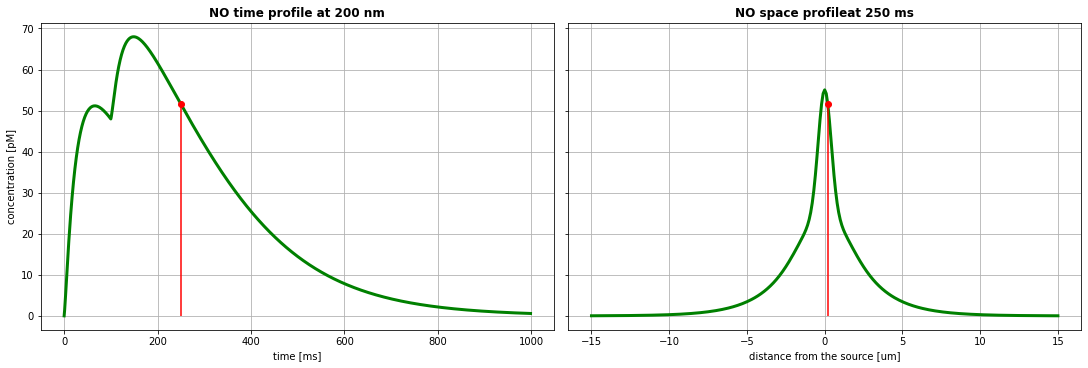

In [9]:
fig1,axes1 = plt.subplots(1,2, figsize=(15,5), constrained_layout =True, sharey=True)
ev_dist = 152
ev_time = 250

axes1[0].plot(time,NO_diffused[ev_dist,:], 'green',linewidth=3, label='at '+str(1000*np.round(distances[ev_dist],decimals=3))+' nm')
#axes1[0].plot(time,spikes*np.max(NO_diffused),'k', alpha = 0.3,linewidth=1)
axes1[0].vlines(time[ev_time],0,NO_diffused[ev_dist,ev_time], color='red')
axes1[0].plot(time[ev_time],NO_diffused[ev_dist,ev_time],'o', color='red')
axes1[0].grid()
axes1[0].set_xlabel('time [ms]')
axes1[0].set_ylabel('concentration [pM]')
axes1[0].set_title('NO time profile at '+str(np.round(1000*distances[ev_dist]).astype(int))+' nm', fontweight ='bold')
axes1[1].plot(distances,NO_diffused[:,ev_time], 'green',linewidth=3, label='at '+str(np.round(time[ev_time],decimals=3))+' ms')
axes1[1].vlines(distances[ev_dist],0,NO_diffused[ev_dist,ev_time], color='red')
axes1[1].plot(distances[ev_dist],NO_diffused[ev_dist,ev_time],'o', color='red')
axes1[1].grid()
axes1[1].set_xlabel('distance from the source [um]')
axes1[1].set_title('NO space profileat '+str(np.round(time[ev_time],decimals=3))+' ms', fontweight ='bold')

Text(0.5, 1.0, 'NO space profile at 250 ms')

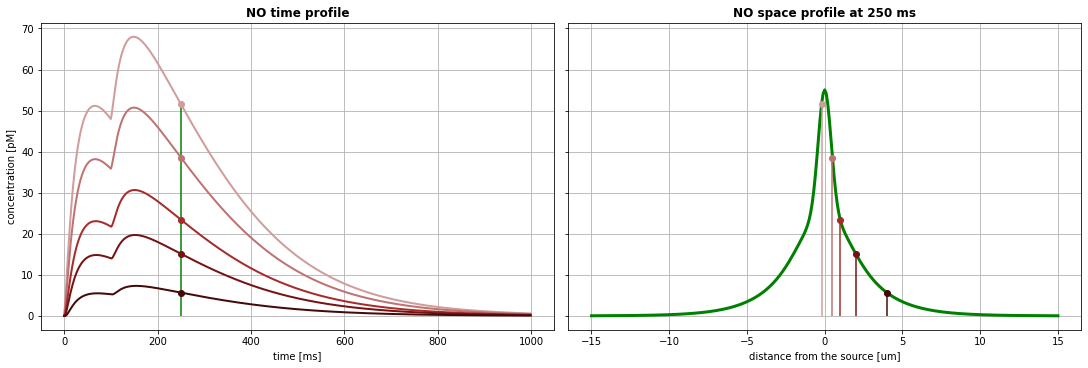

In [10]:
fig2,axes2 = plt.subplots(1,2, figsize=(15,5), constrained_layout =True, sharey=True)
ev_times = [150,200,250,400,550]
ev_dists = [148,155,160,170,190]
ev_dist = 160
ev_time = 250
colors = ['#d09c9c','#bf7272','#a72b2b','#761212','#440909']

axes2[1].plot(distances,NO_diffused[:,ev_time], 'green',linewidth=3, label='at '+str(np.round(time[ev_time],decimals=3))+' ms')
axes2[0].vlines(time[ev_time],0,np.max(NO_diffused[ev_dists,ev_time]), color='green')
for i,ev_d in enumerate(ev_dists):
    axes2[0].plot(time,NO_diffused[ev_d,:], color=colors[i],linewidth=2, label='at '+str(np.round(distances[ev_d],decimals=3))+' um')
    axes2[0].plot(time[ev_time],NO_diffused[ev_d,ev_time],'o', color=colors[i])
    axes2[1].vlines(distances[ev_d],0,NO_diffused[ev_d,ev_time], color=colors[i])
    axes2[1].plot(distances[ev_d],NO_diffused[ev_d,ev_time],'o', color=colors[i])

axes2[0].grid()
axes2[0].set_xlabel('time [ms]')
axes2[0].set_ylabel('concentration [pM]')
axes2[0].set_title('NO time profile', fontweight ='bold')

axes2[1].grid()
axes2[1].set_xlabel('distance from the source [um]')
axes2[1].set_title('NO space profile at '+str(np.round(time[ev_time],decimals=3))+' ms', fontweight ='bold')

Text(0.5, 1.0, 'NO space profile')

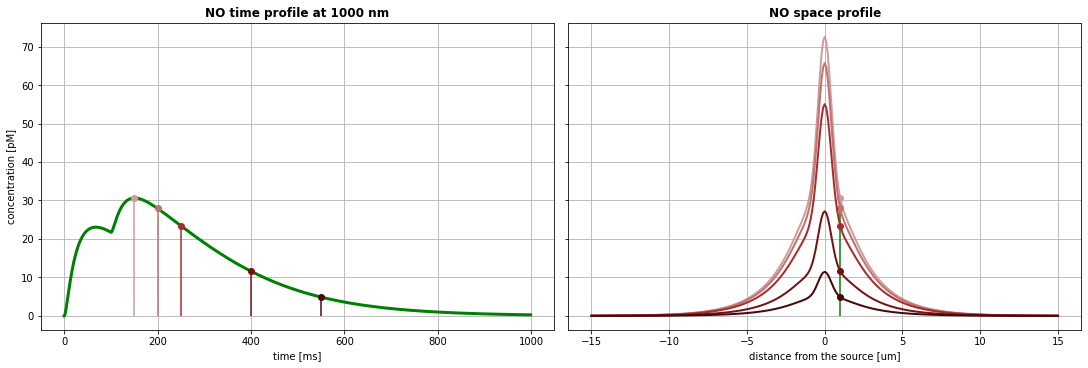

In [11]:
fig2,axes2 = plt.subplots(1,2, figsize=(15,5), constrained_layout =True, sharey=True)
ev_times = [150,200,250,400,550]
ev_dists = [148,155,160,170,190]
ev_dist = 160
ev_time = 250
colors = ['#d09c9c','#bf7272','#a72b2b','#761212','#440909']
axes2[0].plot(time,NO_diffused[ev_dist,:], 'green',linewidth=3, label='at '+str(np.round(time[ev_time],decimals=3))+' ms')
axes2[1].vlines(distances[ev_dist],0,np.max(NO_diffused[ev_dist,ev_times]), color='green')
for i,ev_t in enumerate(ev_times):
    axes2[1].plot(distances,NO_diffused[:,ev_t], color=colors[i],linewidth=2, label='at '+str(np.round(distances[ev_d],decimals=3))+' um')
    axes2[1].plot(distances[ev_dist],NO_diffused[ev_dist,ev_t],'o', color=colors[i])
    axes2[0].vlines(time[ev_t],0,NO_diffused[ev_dist,ev_t], color=colors[i])
    axes2[0].plot(time[ev_t],NO_diffused[ev_dist,ev_t],'o', color=colors[i])
axes2[0].grid()
axes2[0].set_xlabel('time [ms]')
axes2[0].set_ylabel('concentration [pM]')
axes2[0].set_title('NO time profile at '+str(np.round(1000*distances[ev_dist]).astype(int))+' nm', fontweight ='bold')

axes2[1].grid()
axes2[1].set_xlabel('distance from the source [um]')
axes2[1].set_title('NO space profile', fontweight ='bold')

## Plot [NO] evaluated in certain point in space (probes)

In [ ]:
fig2,axes2 = plt.subplots(1,1, figsize=(15,5), constrained_layout =True, sharey=True)
probe_id = 0
probe = sim.NO_in_ev_points[:,probe_id]
distances = sim.distances
axes2.plot(time,probe, 'green',linewidth=3)
axes2.grid()
axes2.set_xlabel('time [ms]')
axes2.set_ylabel('concentration [pM]')
axes2.set_title('NO concentration evaluated in probe #'+str(probe_id), fontweight ='bold')

## Compare Different Stimuli
#TODO da sistemare 

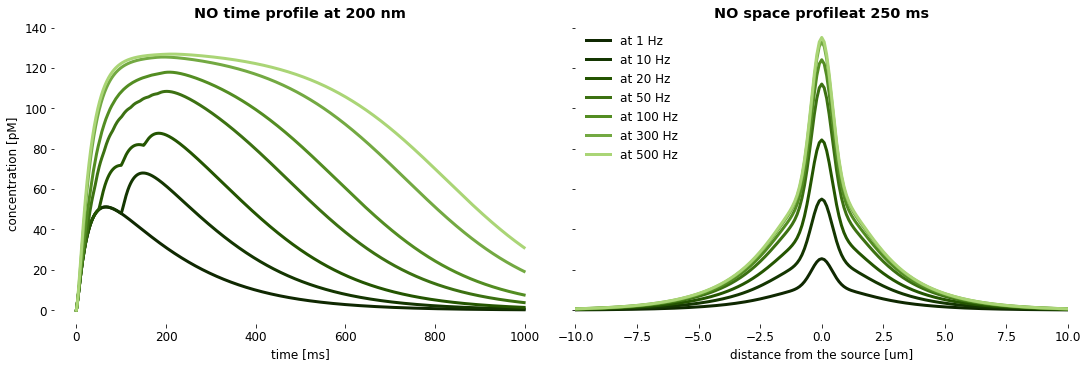

In [17]:
nNOS_coordinates = np.array([[0,0,0]])

ev_point_ids = [5,6,7]
ev_point_coordinates = np.array([[0,0,0],[1,1,1],[17,17,17]])

sources_id = [0]
distances = np.arange(-15, 15.1, 0.1)
start = 0
stop = 200
input_rates = [1, 10, 20, 50, 100, 300, 500]
time = np.arange(0,1000)
colors = ['#0F2801','#143601','#245501','#3C7112','#538D22','#73A942', '#AAD576']
plt.rcParams.update({'font.size': 12})
fig1,axes1 = plt.subplots(1,2, figsize=(15,5), constrained_layout =True, sharey=True)

ev_dist = 152
ev_time = 250

axes1[0].set_xlabel('time [ms]')
axes1[0].set_frame_on(False)
axes1[0].set_ylabel('concentration [pM]')
axes1[0].set_title('NO time profile at '+str(np.round(1000*distances[ev_dist]).astype(int))+' nm', fontweight ='bold')
axes1[1].set_xlabel('distance from the source [um]')
axes1[1].set_xlim(-10,10)
axes1[1].set_title('NO space profileat '+str(np.round(time[ev_time],decimals=3))+' ms', fontweight ='bold')
axes1[1].set_frame_on(False)

for k,rate in enumerate(input_rates):

    spikes = regular_spikes(start,stop,dt,rate,len(time))
    t = np.arange(len(spikes_poisson)) * dt
    time_stamps = t[spikes_poisson.astype(bool)]

    Calm2C = 0
    nNOS = 0
    NO_produced_t0 = 0
    NO_produced_t1 = 0
    NO_diffused = np.zeros((len(distances),len(time)))
    u = np.zeros((len(distances)))
    
    for i in range(0,len(time)-1,1):    
        nNOS, Calm2C, NO_produced_t1 = Production_function(dt,spikes[i],Calm2C,nNOS,tauCa,tauNOS1,tauNOS2,A)
        u, NO = Diffusion_function(dt,u,Green_LUT,NO_produced_t0,NO_produced_t1, B)
        NO_produced_t0 = NO_produced_t1
        NO_diffused[:,i+1] = NO
    
    axes1[0].plot(time,NO_diffused[ev_dist,:], color=colors[k],linewidth=3, label='at '+str(rate)+' Hz')
    axes1[1].plot(distances,NO_diffused[:,ev_time],color=colors[k],linewidth=3, label='at '+str(rate)+' Hz')

plt.legend(loc= 'upper left', frameon=False)

    